In [1]:
import os
import pandas as pd
import json

In [2]:
# Define the path to the experiments directory
experiments_dir = "experiments"

# List to store the results for each sub-directory
results = []

# Ensure the experiments directory exists before running
if os.path.exists(experiments_dir):
    # Iterate through each item in the experiments directory
    for entry in os.listdir(experiments_dir):
        sub_dir = os.path.join(experiments_dir, entry)
        
        # Check if the current item is actually a directory
        if os.path.isdir(sub_dir):
            metrics_file = os.path.join(sub_dir, "training_metrics.csv")
            hp_file = os.path.join(sub_dir, "hyperparameters.json")
            
            # Check if the metrics CSV exists in this sub-directory
            if os.path.exists(metrics_file):
                try:
                    df = pd.read_csv(metrics_file)
                    
                    # Verify that the required columns exist
                    required_cols = ['frame_f1', 'mean_iou', 'segment_f1']
                    if all(col in df.columns for col in required_cols):
                        
                        # Determine the best epoch by summing the 3 metrics (Change this math if you want different weights)
                        df['combined_score'] = df['frame_f1'] + df['mean_iou'] + df['segment_f1']
                        
                        # Find the index of the row with the highest combined score
                        best_idx = df['combined_score'].idxmax()
                        best_row = df.iloc[best_idx]
                        
                        # Get the epoch number (Assumes an 'epoch' column exists, otherwise uses row index + 1)
                        best_epoch = int(best_row['epoch']) if 'epoch' in df.columns else best_idx + 1
                        
                        frame_f1 = best_row['frame_f1']
                        mean_iou = best_row['mean_iou']
                        segment_f1 = best_row['segment_f1']
                        
                        # Look for the description in hyperparameters.json
                        description = "N/A"
                        if os.path.exists(hp_file):
                            with open(hp_file, 'r', encoding='utf-8') as f:
                                hp_data = json.load(f)
                                description = hp_data.get('description', "N/A")
                                
                        # Append the gathered data to our results list
                        results.append({
                            "Sub-directory": entry,
                            "Best Epoch": best_epoch,
                            "Frame F1": round(frame_f1, 4),
                            "Mean IoU": round(mean_iou, 4),
                            "Segment F1": round(segment_f1, 4),
                            "Description": description
                        })
                    else:
                        print(f"Skipping '{entry}': Missing one or more required metric columns.")
                except Exception as e:
                    print(f"Error processing '{entry}': {e}")
else:
    print(f"Directory '{experiments_dir}' not found. Please make sure it is in the same directory as this notebook.")

# Create a DataFrame for a clean table rendering in Jupyter Notebook
results_df = pd.DataFrame(results)

# Display the resulting dataframe
display(results_df)

,Sub-directory,Best Epoch,Frame F1,Mean IoU,Segment F1,Description
0,decoupled_stgcn_bimamba-04,28,0.6408,0.6243,0.4142,N/A
1,stgcn_mamba-37,25,0.6658,0.7250,0.6227,overlap ratio (50/128)
2,decoupled_stgcn_mamba-02,28,0.6761,0.5233,0.4884,N/A
3,decoupled_stgcn_bimamba-02,18,0.6816,0.5363,0.4959,N/A
4,decoupled_stgcn_mamba-05,27,0.6398,0.6273,0.4193,N/A
...,...,...,...,...,...,...
62,stgcn_mamba-38,26,0.6906,0.5854,0.6368,^^^
63,decoupled_stgcn_mamba-04,29,0.6375,0.6209,0.4101,N/A
64,stgcn_mamba-42,50,0.7279,0.7612,0.6871,overlap ratio (75/128)
65,stgcn_mamba-47,50,0.7023,0.7470,0.6639,overlap ratio (64/128)


In [ ]:
# Define the path to the experiments directory
experiments_dir = "experiments"

# --- FILTER OPTIONS ---
# Put the exact model_name you want to filter by (e.g., "stgcn_mamba", "bimamba").
# If you want to process ALL directories, leave this as None.
target_model_name = "stgcn_mamba"  # Example: "stgcn_mamba" or "bimamba"

# --- NEW: MULTIPLE HYPERPARAMETERS DISPLAY OPTION ---
# Use a list to define all the hyperparameters you want to display as separate columns.
# If you don't want to display any, just leave it as an empty list: []
target_hyperparameters = ["loss_function", "window_size", "overlap"]
# ----------------------------------------------------

# --- HIGHLIGHT SPECIFIC SUB-DIRECTORIES ---
# Add sub-directory names here to highlight their rows in the output.
# Leave empty to disable this feature.
highlight_subdirectories = [
    27, 31, 33, 37
]

highlight_subdirectories = [
    f"{target_model_name}-{int(item):02d}" if isinstance(item, int) or (isinstance(item, str) and item.isdigit()) else item
    for item in highlight_subdirectories
]
# ----------------------------------------------------

# List to store the results for each sub-directory
results = []

# Function to extract the numeric suffix from the directory name after the dash.
def extract_suffix_number(directory_name):
    try:
        suffix = directory_name.split('-', 1)[1]
        return int(''.join(filter(str.isdigit, suffix)) or 0)
    except Exception:
        return float('inf')

# Ensure the experiments directory exists before running
if os.path.exists(experiments_dir):
    # Gather directory entries and sort by suffix number after the dash
    entries = [entry for entry in os.listdir(experiments_dir) if os.path.isdir(os.path.join(experiments_dir, entry))]
    entries.sort(key=extract_suffix_number)

    for entry in entries:
        # Check if the directory matches our selected model
        if target_model_name is not None:
            if not entry.startswith(f"{target_model_name}-"):
                continue # Skip this folder and move to the next one
                
        sub_dir = os.path.join(experiments_dir, entry)
        metrics_file = os.path.join(sub_dir, "training_metrics.csv")
        hp_file = os.path.join(sub_dir, "hyperparameters.json")
        
        # Extract multiple hyperparameters early
        description = "N/A"
        # Initialize a dictionary with "N/A" for all requested hyperparameters
        hp_values = {hp: "N/A" for hp in target_hyperparameters}
        
        if os.path.exists(hp_file):
            try:
                with open(hp_file, 'r', encoding='utf-8') as f:
                    hp_data = json.load(f)
                    description = hp_data.get('description', "N/A")
                    
                    # Loop through the list and grab each targeted hyperparameter
                    for hp in target_hyperparameters:
                        hp_values[hp] = hp_data.get(hp, "N/A")
            except json.JSONDecodeError:
                print(f"Warning: Could not parse {hp_file}")
        
        # Check if the metrics CSV exists in this sub-directory
        if os.path.exists(metrics_file):
            try:
                df = pd.read_csv(metrics_file)
                
                # Verify that the required columns exist
                required_cols = ['frame_f1', 'mean_iou', 'segment_f1']
                if all(col in df.columns for col in required_cols):
                    
                    # Determine the best epoch by summing the 3 metrics
                    df['combined_score'] = df['frame_f1'] + df['mean_iou'] + df['segment_f1']
                    df['average_score'] = df['combined_score'] / 3
                    
                    # Find the index of the row with the highest combined score
                    best_idx = df['combined_score'].idxmax()
                    best_row = df.iloc[best_idx]
                    
                    # Get the epoch number (Assumes an 'epoch' column exists, otherwise uses row index + 1)
                    best_epoch = int(best_row['epoch']) if 'epoch' in df.columns else best_idx + 1
                    
                    frame_f1 = best_row['frame_f1']
                    mean_iou = best_row['mean_iou']
                    segment_f1 = best_row['segment_f1']
                    average_score = best_row['average_score']
                        
                    # Build the base dictionary for this row
                    # --- FIX: Format as strict strings to stop Pandas from auto-padding zeros ---
                    result_dict = {
                        "Sub-directory": entry,
                        "Best Epoch": best_epoch,
                        "Frame F1": f"{frame_f1:.3f}",
                        "Mean IoU": f"{mean_iou:.3f}",
                        "Segment F1": f"{segment_f1:.3f}",
                        "Average score": f"{average_score:.3f}"
                    }
                    
                    # Dynamically add EACH target hyperparameter to the table
                    for hp in target_hyperparameters:
                        result_dict[f"HP: {hp}"] = hp_values[hp]
                        
                    # Add description at the very end so it sits on the far right of the table
                    result_dict["Description"] = description                            
                    
                    results.append(result_dict)
                else:
                    print(f"Skipping '{entry}': Missing one or more required metric columns.")
            except Exception as e:
                print(f"Error processing '{entry}': {e}")
else:
    print(f"Directory '{experiments_dir}' not found. Please make sure it is in the same directory as this notebook.")

# Create a DataFrame for a clean table rendering in Jupyter Notebook
results_df = pd.DataFrame(results)

# Display the resulting dataframe WITHOUT the index AND with a colored column
if not results_df.empty:
    
    # Define the color you want for the Average score column here
    highlight_color = 'rgb(72, 73, 44)' 
    # Define the color for rows matching highlight_subdirectories
    highlighted_row_color = 'rgb(35, 46, 56)'
    
    def score_style(value, hue=120):
        try:
            score = float(value)
        except (ValueError, TypeError):
            return ""

        # Use lighter tones for lower values and darker tones for higher values.
        lightness = 90 - score * 90
        lightness = max(10, min(60, lightness))
        return f"background-color: hsl({hue}, 0%, {lightness:.1f}%)"

    try:
        # For newer versions of Pandas (>= 1.4.0)
        styled_df = results_df.style.hide(axis="index")
        
        if highlight_subdirectories:
            highlight_set = set(highlight_subdirectories)
            def highlight_selected(row):
                return [
                    f"background-color: {highlighted_row_color}" if row["Sub-directory"] in highlight_set else ""
                    for _ in row
                ]
            styled_df = styled_df.apply(highlight_selected, axis=1)

        styled_df = styled_df.applymap(score_style, subset=['Average score'])
        styled_df = styled_df.applymap(lambda value: score_style(value, hue=0), subset=['Frame F1', 'Mean IoU', 'Segment F1'])
        display(styled_df)
    except AttributeError:
        # Fallback for older versions of Pandas
        styled_df = results_df.style.hide_index()

        if highlight_subdirectories:
            highlight_set = set(highlight_subdirectories)
            def highlight_selected(row):
                return [
                    f"background-color: {highlighted_row_color}" if row["Sub-directory"] in highlight_set else ""
                    for _ in row
                ]
            styled_df = styled_df.apply(highlight_selected, axis=1)

        styled_df = styled_df.applymap(score_style, subset=['Average score'])
        styled_df = styled_df.applymap(lambda value: score_style(value, hue=0), subset=['Frame F1', 'Mean IoU', 'Segment F1'])
        display(styled_df)
else:
    print("No results found. Either the directory is empty, or no folders matched your criteria.")

/tmp/ipykernel_49037/755819706.py:158: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = styled_df.applymap(score_style, subset=['Average score'])
/tmp/ipykernel_49037/755819706.py:159: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = styled_df.applymap(lambda value: score_style(value, hue=0), subset=['Frame F1', 'Mean IoU', 'Segment F1'])


Sub-directory,Best Epoch,Frame F1,Mean IoU,Segment F1,Average score,HP: loss_function,HP: window_size,HP: overlap,Description
stgcn_mamba-01,26,0.601,0.565,0.480,0.549,N/A,1000,200,N/A
stgcn_mamba-02,14,0.669,0.537,0.488,0.565,N/A,1000,200,N/A
stgcn_mamba-03,19,0.675,0.531,0.492,0.566,N/A,1000,200,N/A
stgcn_mamba-04,21,0.678,0.402,0.470,0.517,weighted_ce,1000,200,N/A
stgcn_mamba-05,29,0.638,0.625,0.411,0.558,standard_ce,1000,200,N/A
stgcn_mamba-06,21,0.646,0.613,0.433,0.564,standard_ce,1000,200,N/A
stgcn_mamba-07,29,0.654,0.670,0.496,0.607,standard_ce,512,200,N/A
stgcn_mamba-08,28,0.546,0.277,0.023,0.282,standard_ce,4096,0,N/A
stgcn_mamba-09,27,0.554,0.448,0.174,0.392,standard_ce,2048,0,N/A
stgcn_mamba-10,20,0.553,0.485,0.187,0.408,standard_ce,2048,0,N/A


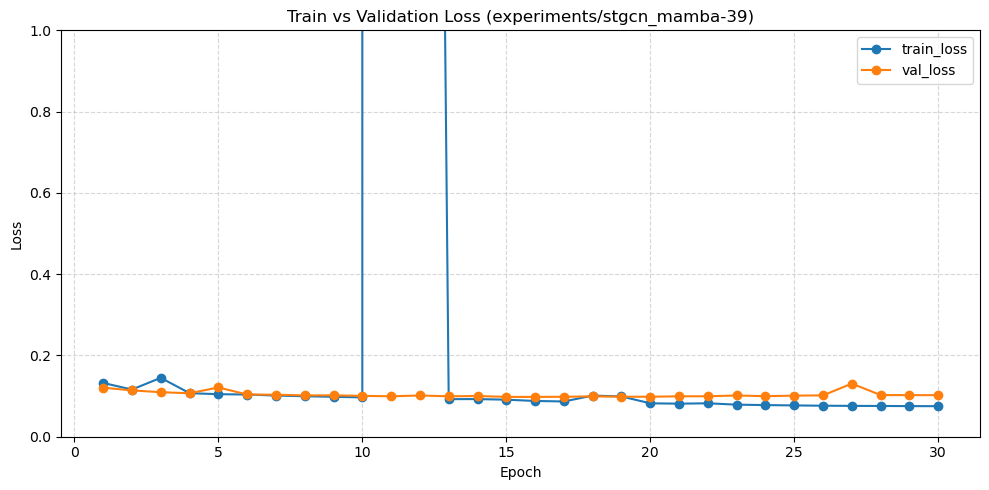

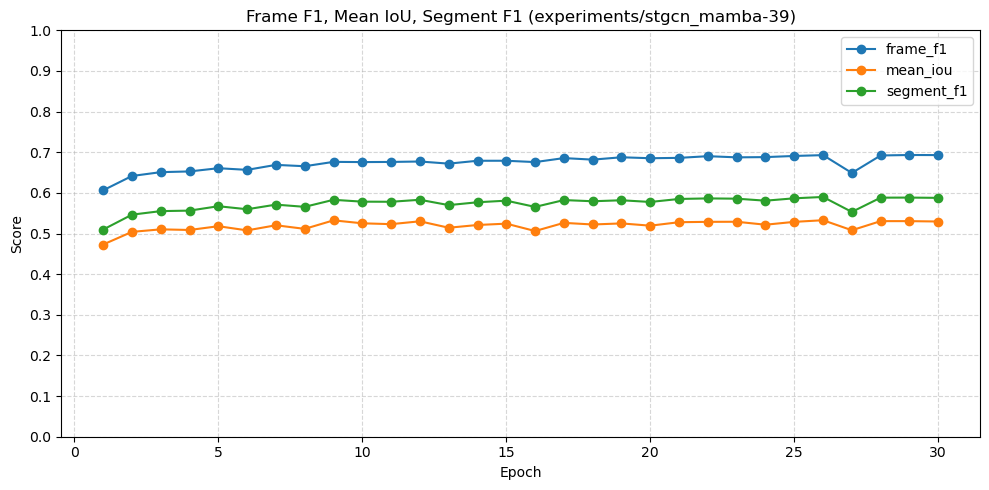

In [4]:
# Select the specific experiment sub-directory to plot
selected_subdir = os.path.join("experiments", "stgcn_mamba-39")
metrics_file = os.path.join(selected_subdir, "training_metrics.csv")

import matplotlib.pyplot as plt
import numpy as np

# Load the metrics CSV and ignore rows where epoch is not an integer
raw_df = pd.read_csv(metrics_file, dtype=str)
raw_df['epoch'] = pd.to_numeric(raw_df['epoch'], errors='coerce')
df = raw_df[raw_df['epoch'].notna()].copy()
df['epoch'] = df['epoch'].astype(int)

# Convert the relevant columns to numeric for plotting
for col in ['train_loss', 'val_loss', 'frame_f1', 'mean_iou', 'segment_f1']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort by epoch just in case
df = df.sort_values('epoch')

# Plot 1: train_loss and val_loss
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['train_loss'], marker='o', label='train_loss')
plt.plot(df['epoch'], df['val_loss'], marker='o', label='val_loss')
plt.title(f"Train vs Validation Loss ({selected_subdir})")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: frame_f1, mean_iou, segment_f1
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['frame_f1'], marker='o', label='frame_f1')
plt.plot(df['epoch'], df['mean_iou'], marker='o', label='mean_iou')
plt.plot(df['epoch'], df['segment_f1'], marker='o', label='segment_f1')
plt.title(f"Frame F1, Mean IoU, Segment F1 ({selected_subdir})")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()